In [3]:
import pandas as pd
import numpy as np
import os
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
import re

In [4]:
!pip install transformers torch scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Python314\python.exe -m pip install --upgrade pip


### Cut DS down

In [ ]:
# import pandas as pd
# from sklearn.model_selection import train_test_split

# input_file = "final_v1.csv"
# output_file = "emails_sampled_25k.csv"
# chunksize = 5000
# target_size = 25000

# chunks = []

# # Step 1: Read dataset in chunks and drop duplicates
# for chunk in pd.read_csv(input_file, chunksize=chunksize):
#     chunk = chunk[['final_text', 'is_spam']].drop_duplicates(subset='final_text')
#     chunks.append(chunk)

# # Combine all chunks
# df = pd.concat(chunks, ignore_index=True)

# # Step 2: Stratified sampling to 25k rows
# df_sampled, _ = train_test_split(
#     df,
#     train_size=target_size,
#     stratify=df['is_spam'],
#     random_state=42
# )

# # Step 3: Save reduced dataset
# df_sampled.to_csv(output_file, index=False)

# print(f"Sampled dataset saved to {output_file}")
# print(df_sampled['is_spam'].value_counts())

In [ ]:
from transformers import BertTokenizer, BertModel
import torch

# for combining features
from scipy import sparse
import numpy as np

In [7]:
df = pd.read_csv("emails_sampled_25k.csv")

In [ ]:
# Check for NaNs in the processed text
num_nans = df['final_text'].isnull().sum()
print("NaNs in final_text:", num_nans)

# Check for empty strings (after stripping whitespace)
num_empty = (df['final_text'].str.strip() == '').sum()
print("Empty strings in final_text:", num_empty)


NaNs in final_text: 0
Empty strings in final_text: 0


In [9]:
df = df.dropna(subset=['final_text']) # Drop rows that are NaN
df = df.reset_index(drop=True)


In [10]:
print(df.isnull().sum())


final_text    0
is_spam       0
dtype: int64


## Data Engineering/Extraction

### TF-IDF Vectorization

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,    # limit vocabulary size, 5000 features (these features are the most “important” words or n-grams from our corpus)
    ngram_range=(1, 2),   # unigrams + bigrams
    stop_words='english'  # skip common words
)

X_tfidf = tfidf.fit_transform(df['final_text'].fillna(''))
 #feature matrix, the numerical representation of all our documents


TF-IDF extracts each unique word (or n-gram), builds a vocabulary

Builds/returns a vocabulary of all unique words (or n-grams) it learned from your corpus. Above shows only the words that actually appear in the first email, along with their importance scores.

### Inspect / Analyze TF-IDF

In [12]:
vocab = tfidf.get_feature_names_out()
print(len(vocab))        # should be ≤ max_features
print(vocab[:20])        # preview first 20 words

5000
['aa' 'aaa'
 'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa'
 'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa'
 'aaron' 'ab' 'abacha' 'abandoned' 'abidjan' 'ability' 'able' 'abraham'
 'abroad' 'absence' 'absolute' 'absolutely' 'abstract' 'abuse' 'ac'
 'ac uk']


In [13]:
# View words specifically 
word_vocab = [w for w in vocab if re.match(r'^[a-zA-Z]+$', w)]
print(f"Words only: {len(word_vocab)}")
print(word_vocab[:50])  # preview first 50 words


Words only: 4204
['aa', 'aaa', 'aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa', 'aaron', 'ab', 'abacha', 'abandoned', 'abidjan', 'ability', 'able', 'abraham', 'abroad', 'absence', 'absolute', 'absolutely', 'abstract', 'abuse', 'ac', 'academic', 'accept', 'acceptable', 'acceptance', 'accepted', 'access', 'accessible', 'accident', 'accommodation', 'accordance', 'according', 'accordingly', 'account', 'accountant', 'accounting', 'accuracy', 'accurate', 'achieve', 'acl', 'acm', 'acpi', 'acquire', 'acquired', 'acquisition', 'acrobat', 'act', 'action', 'active', 'activity', 'actual', 'actually', 'acy']


Above checks TF-IDF vocabulary

In [14]:
i = 0  # first email
df_single = pd.DataFrame(X_tfidf[i].T.todense(), index=tfidf.get_feature_names_out(), columns=["tfidf"])
print(df_single[df_single.tfidf > 0]) #Filter to only non-zero TF-IDF scores


                  tfidf
check          0.173323
cheer          0.235662
christmas      0.308822
documentation  0.253785
gave           0.257399
hi             0.181606
holiday        0.284560
know           0.265788
know need      0.301113
let            0.158653
let know       0.185824
need           0.131838
pay            0.204135
place          0.181754
query          0.268766
stuff          0.242129
think          0.158267
thought        0.210732
want           0.143228
way            0.149479
work           0.134748


In [15]:
sparsity = 1.0 - (X_tfidf.count_nonzero() / (X_tfidf.shape[0] * X_tfidf.shape[1]))
print(f"Sparsity: {sparsity:.2%}")


Sparsity: 98.75%


### top words by TF-IDF score

In [16]:
# tfidf (TfidfVectorizer) and X_tfidf assumed present
feature_names = tfidf.get_feature_names_out()
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=feature_names)

# average TF-IDF in spam vs non-spam
avg_spam = tfidf_df[df['is_spam'] == 1].mean(axis=0)
avg_nonspam = tfidf_df[df['is_spam'] == 0].mean(axis=0)

spam_top = avg_spam.sort_values(ascending=False).head(40)
print("Top TF-IDF words in spam (avg):")
print(spam_top)


Top TF-IDF words in spam (avg):
watch            0.031432
replica          0.031117
com              0.024672
account          0.020642
money            0.019879
http             0.019528
click            0.018953
email            0.018929
replica watch    0.015449
price            0.015198
offer            0.014865
company          0.014506
life             0.014389
site             0.014354
bank             0.014037
time             0.013628
best             0.013491
free             0.013471
fund             0.013334
health           0.012936
want             0.012444
online           0.012435
business         0.012345
new              0.012322
mail             0.011416
rolex            0.011185
product          0.011116
order            0.011112
day              0.010774
dear             0.010503
www              0.010503
information      0.010456
need             0.010455
love             0.010245
country          0.010229
mr               0.010136
help             0.010056
visit 

## Additional features (to test)

- Common keywords
- word count
- unique word count
- number frequency 

### Exploring common phishing keywords

In [17]:
key_words = [
    'click', 'login', 'transfer', 'free', 'win', 'payment', 'transaction', 'transfer', 'money', 'tax', 'receipt',
    'urgent', 'verify account', 'act', 'confirm', 'view', 'unusual', "limited", 
    "new", "message", "required", "action", "document", "verification","special", "offer"

]

# Dictionary to hold keyword summary
kw_summary = {}

# Loop through each keyword
for w in key_words:
    # Detect presence of keyword (boolean Series, not added to df)
    has_kw = df['final_text'].str.contains(r'\b' + re.escape(w) + r'\b', regex=True, case=False)
    
    # Compute metrics
    tp = ((has_kw) & (df['is_spam'] == 1)).sum()  # spam emails containing keyword
    fp = ((has_kw) & (df['is_spam'] == 0)).sum()  # non-spam emails containing keyword
    in_email = has_kw.sum()                       # total emails containing keyword

    # Store in summary
    kw_summary[w] = {
        'in_email': in_email,
        'spam_hits': tp,
        'nonspam_hits': fp,
        'spam_likelihood': tp / (in_email + 1e-9)
    }

# Convert to DataFrame for viewing
kw_df = pd.DataFrame.from_dict(kw_summary, orient='index').sort_values('spam_likelihood', ascending=False)
kw_df

spam_likelihood_dict = kw_df['spam_likelihood'].to_dict()

def keyword_likelihood_score(text):
    score = 0
    for kw, likelihood in spam_likelihood_dict.items():
        if re.search(r'\b' + re.escape(kw) + r'\b', text, flags=re.IGNORECASE):
            score += likelihood
    return score

# Add feature to DF
df['kw_score'] = df['final_text'].apply(keyword_likelihood_score)



In [18]:
df.sample(10)

,final_text,is_spam,kw_score
10957,probably know maintain dor patch maint nichola...,0,0.336611
9188,techrepublic webcasts techrepublic webcasts la...,0,0.392450
17790,hello would like offer localized software vers...,1,0.677576
18133,cnn alert custom alert alert name custom alert...,1,1.085440
9421,url date supplied new ish strange horizon inte...,0,0.336611
469,mon sep tom wrote set pas around enough people...,0,0.000000
8591,hello everyone invitation map sandeep home see...,0,0.000000
19286,short energy feeling depressed resolution chec...,1,0.513049
11143,welcome golden gate casino offer unique possib...,1,2.302596
13635,de ire tonight green card online chance come h...,1,0.000000


In [19]:
import string
import re

df['word_count'] = df['final_text'].apply(lambda x: len(str(x).split()))
df['unique_word_count'] = df['final_text'].apply(lambda x: len(set(str(x).split())))

def count_numbers(text):
    return len(re.findall(r'\d+', text))

df['num_count'] = df['final_text'].apply(count_numbers)


def repeated_punct_symbols(text, min_repeat=2):
    text = str(text)
    # Define suspicious symbols (can adjust based on dataset)
    suspicious_chars = string.punctuation  # includes all standard punctuation
    
    # Regex: any character in suspicious_chars repeated min_repeat or more times
    pattern = r'([{}])\1{{{}}}'.format(re.escape(suspicious_chars), min_repeat - 1)
    
    # Return 1 if any repeated pattern found, else 0
    return int(bool(re.search(pattern, text)))

In [20]:
df.sample(10)

,final_text,is_spam,kw_score,word_count,unique_word_count,num_count
21658,purine quicken keats idiotic posit keats euras...,1,0.000000,50,34,0
13738,begin forwarded text date wed oct john denker ...,0,0.547071,265,213,0
10762,friend mine tried writing lady specified unive...,0,0.000000,45,42,0
11623,email commercial advertisement sent compliance...,1,1.874740,108,82,0
7556,der ultimative erotiknewsletter alle seiten wu...,1,0.000000,96,73,0
5070,mr grace obaseki flat block nnpc quarter garki...,1,5.161114,295,226,0
19822,internal external candidate interviewed ena tr...,0,0.000000,80,69,0
12006,pani grazyno dziekuje bardzo za wiadomosc auto...,0,0.000000,59,51,0
7650,steve order book discount sending copy today g...,0,0.336611,41,30,0
18708,treatment make lassie boggle renewed dimension...,1,0.000000,25,25,0


### Unsual/rare word feature 
- signal for unusual or suspicious words

In [21]:
from collections import Counter

all_words = " ".join(df['final_text']).split()  # Use your cleaned text column

# Count the frequency of each word
word_counts = Counter(all_words)

# Define and store rare words (appearing < n times across your entire corpus) 
rare_words = {w for w, c in word_counts.items() if c < 4}

# Function to count rare words per email
def count_rare_words(text):
    return sum(1 for w in str(text).split() if w in rare_words)

df['rare_word_count'] = df['final_text'].apply(count_rare_words)


In [22]:
df['num_urls'] = df['final_text'].str.count(r'http[s]?://')
df['num_emails'] = df['final_text'].str.count(r'\b[\w.-]+@[\w.-]+\.\w+\b')

threshold = 4
df['many_rare_words'] = (df['rare_word_count'] >= threshold).astype(int)


In [23]:
df.sample(10)

,final_text,is_spam,kw_score,word_count,unique_word_count,num_count,rare_word_count,num_urls,num_emails,many_rare_words
10580,find attached egm management summary hot list ...,0,0.272747,32,26,0,0,0,0,0
19970,e mail apparently reference lipscomb mocane la...,0,0.272747,135,79,0,4,0,0,1
24746,attached updated wip report week regard angie ...,0,0.000000,14,14,0,1,0,0,0
4016,great news nice see hard work great attitude g...,0,1.548182,721,329,0,0,0,0,0
13062,get canm ob first thing today going explode ch...,1,1.785948,493,330,0,6,0,0,1
6508,louise trying get something arranged friday ub...,0,0.785797,146,92,0,3,0,0,0
21177,hi tim saying would perfectly acceptable loop ...,0,0.251786,293,154,0,8,0,0,1
14807,dear ccollaborators placed new version propose...,0,0.843654,133,105,0,8,0,0,1
6766,ready make love moment notice ci li available ...,1,0.992245,84,72,0,7,0,0,1
17034,simplest way increase length least inch click ...,1,0.692990,9,9,0,1,0,0,0


## DistilBERT

In [24]:
from transformers import DistilBertTokenizer, DistilBertModel
import torch
import numpy as np

# Load lightweight DistilBERT tokenizer and model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased')

# Force CPU usage
device = torch.device('cpu')
model.to(device)

# Extract email text and labels
emails = df['final_text'].tolist()
labels = df['is_spam'].tolist()

def get_light_bert_embeddings(texts, batch_size=4):
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        # Tokenize batch
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            return_tensors="pt"
        ).to(device)

        # No gradient computation
        with torch.no_grad():
            outputs = model(**inputs)
            cls_vecs = outputs.last_hidden_state[:, 0, :].cpu().numpy()  # CLS token

        all_embeddings.append(cls_vecs)

        print(f"Processed {i + len(batch)} / {len(texts)} emails")

    # Stack all embeddings
    return np.vstack(all_embeddings)

# Run CPU-friendly DistilBERT embeddings
cls_embeddings = get_light_bert_embeddings(emails, batch_size=4)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\lle34\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\lle34\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Processed 4 / 25000 emails
Processed 8 / 25000 emails
Processed 12 / 25000 emails
Processed 16 / 25000 emails
Processed 20 / 25000 emails
Processed 24 / 25000 emails
Processed 28 / 25000 emails
Processed 32 / 25000 emails
Processed 36 / 25000 emails
Processed 40 / 25000 emails
Processed 44 / 25000 emails
Processed 48 / 25000 emails
Processed 52 / 25000 emails
Processed 56 / 25000 emails
Processed 60 / 25000 emails
Processed 64 / 25000 emails
Processed 68 / 25000 emails
Processed 72 / 25000 emails
Processed 76 / 25000 emails
Processed 80 / 25000 emails
Processed 84 / 25000 emails
Processed 88 / 25000 emails
Processed 92 / 25000 emails
Processed 96 / 25000 emails
Processed 100 / 25000 emails
Processed 104 / 25000 emails
Processed 108 / 25000 emails
Processed 112 / 25000 emails
Processed 116 / 25000 emails
Processed 120 / 25000 emails
Processed 124 / 25000 emails
Processed 128 / 25000 emails
Processed 132 / 25000 emails
Processed 136 / 25000 emails
Processed 140 / 25000 emails
Processed 1

## Training

In [27]:
df['is_spam'].value_counts(normalize=True) * 100 #percent dsitrubution

is_spam
0    53.732
1    46.268
Name: proportion, dtype: float64

In [28]:
numeric_features = ['kw_score', 'word_count', 'unique_word_count','rare_word_count']
X_numeric = df[numeric_features]  # shape: (n_samples, n_numeric_features)

In [ ]:
from scipy import sparse
from scipy.sparse import csr_matrix
from sklearn.preprocessing import MaxAbsScaler

# TF-IDF features (already sparse)

# 2) BERT embeddings (dense → sparse)
bert_sparse = csr_matrix(cls_embeddings)  # cls_embeddings is already a NumPy array

# 3) Numeric features (dense → sparse → scaled)
numeric_cols = ['kw_score','word_count','unique_word_count','num_count',
                'rare_word_count','num_urls','num_emails','many_rare_words']
X_numeric = df[numeric_cols]

# Convert to sparse
X_numeric_sparse = csr_matrix(X_numeric.values)

# Scale numeric features (keeps sparse format)
scaler = MaxAbsScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric_sparse)

# 4) Combine it all
X_final = sparse.hstack([X_tfidf, bert_sparse, X_numeric_scaled])

print("FINAL SHAPE:", X_final.shape)

FINAL SHAPE: (25000, 5776)


In [ ]:
# from scipy.sparse import hstack, csr_matrix
# from sklearn.preprocessing import MaxAbsScaler

# # Convert numeric features to sparse
# X_numeric_sparse = csr_matrix(X_numeric.values)

# # Scale numeric features
# scaler = MaxAbsScaler()
# X_numeric_scaled = scaler.fit_transform(X_numeric_sparse)

# # Combine TF-IDF (sparse) and numeric (now scaled & sparse)
# X_combined = hstack([X_tfidf, X_numeric_scaled])

# # print(X_combined.shape)  # (n_samples, n_tfidf_features + n_numeric_features)

# from scipy.sparse import csr_matrix
# from sklearn.preprocessing import MaxAbsScaler

# # 1) TF-IDF features (already sparse)
# # X_tfidf


# # 2) BERT embeddings (dense → sparse)
# bert_sparse = csr_matrix(cls_embeddings.numpy())


# # 3) Numeric features (dense → sparse → scaled)
# X_numeric = df[['kw_score','word_count','unique_word_count','num_count',
#                 'rare_word_count','num_urls','num_emails','many_rare_words']]

# # Convert to sparse
# X_numeric_sparse = csr_matrix(X_numeric.values)

# # Scale (keeps sparse format)
# scaler = MaxAbsScaler()
# X_numeric_scaled = scaler.fit_transform(X_numeric_sparse)


# # 4) Combine EVERYTHING
# X_final = sparse.hstack([X_tfidf, bert_sparse, X_numeric_scaled])

# print("FINAL SHAPE:", X_final.shape)


(42999, 5004)


## Train/Test Split

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, labels, test_size=0.2, random_state=42, stratify=labels
)

## Logistic Regression

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

y = df['is_spam']

# Initialize Logistic Regression
model = LogisticRegression(
    solver='saga', 
    max_iter=5000, 
    penalty='l2',
)

# Fit model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9698

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97      2687
           1       0.97      0.97      0.97      2313

    accuracy                           0.97      5000
   macro avg       0.97      0.97      0.97      5000
weighted avg       0.97      0.97      0.97      5000



In [32]:
train_set = accuracy_score(y_train, model.predict(X_train))
test_set = accuracy_score(y_test, model.predict(X_test))

print("Train accuracy:", train_set)
print("Test set acc:",  test_set)

Train accuracy: 0.9847
Test set acc: 0.9698


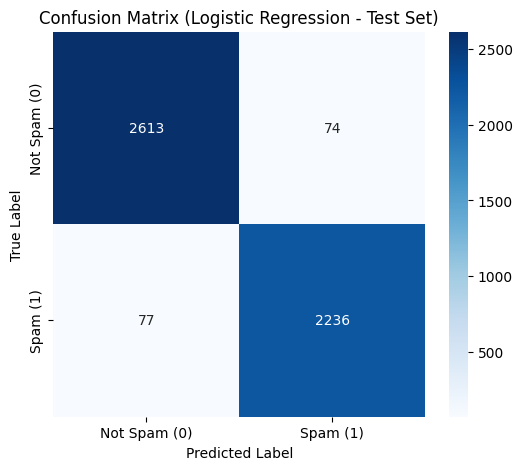

In [33]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam (0)', 'Spam (1)'],  
            yticklabels=['Not Spam (0)', 'Spam (1)'])
plt.title('Confusion Matrix (Logistic Regression - Test Set)')     
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


### Cross-Validation Check

In [35]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_final, y, cv=cv, scoring='accuracy')

print("Cross-validation accuracies:", scores)
print("Mean accuracy: {:.4f} ± {:.4f}".format(scores.mean(), scores.std()))


Cross-validation accuracies: [0.9714 0.9696 0.9728 0.9732 0.9736]
Mean accuracy: 0.9721 ± 0.0015


## Naive Bayes

In [36]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)
y_pred = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nNaive Bayes Report:\n", classification_report(y_test, y_pred))

ValueError: Negative values in data passed to MultinomialNB (input X).

In [ ]:
# Cross validation check
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(nb_model, X_final, y, cv=cv, scoring='accuracy')

print("Naive Bayes cross-val accuracies:", scores)
print("Mean accuracy: {:.4f} ± {:.4f}".format(scores.mean(), scores.std()))

Naive Bayes cross-val accuracies: [0.9372093  0.94209302 0.94465116 0.94046512 0.94720316]
Mean accuracy: 0.9423 ± 0.0034


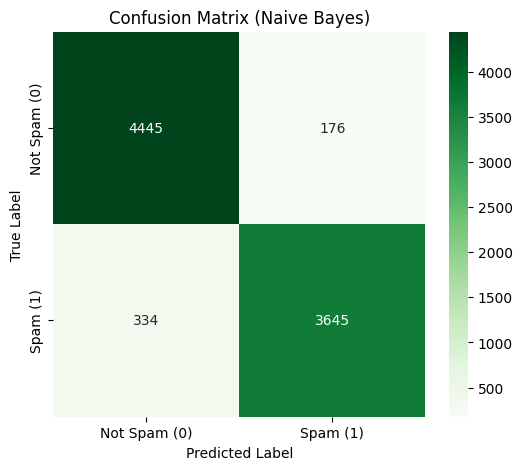

In [ ]:
cm_nb = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Not Spam (0)', 'Spam (1)'],
    yticklabels=['Not Spam (0)', 'Spam (1)']
)
plt.title('Confusion Matrix (Naive Bayes)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## SVM Model

In [37]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nSVM Classification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9744

SVM Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      2687
           1       0.97      0.97      0.97      2313

    accuracy                           0.97      5000
   macro avg       0.97      0.97      0.97      5000
weighted avg       0.97      0.97      0.97      5000



In [39]:
train_set = accuracy_score(y_train, svm_model.predict(X_train))
test_set = accuracy_score(y_test, svm_model.predict(X_test))

print("Train accuracy:", train_set)
print("Test set acc:",  test_set)

Train accuracy: 0.9988
Test set acc: 0.9744


In [ ]:
# Cross validation check
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(svm_model, X_final, y, cv=cv, scoring='accuracy')

print("SVM cross-val accuracies:", scores)
print("Mean accuracy: {:.4f} ± {:.4f}".format(scores.mean(), scores.std()))

SVM cross-val accuracies: [0.97302326 0.97406977 0.97465116 0.9744186  0.97557856]
Mean accuracy: 0.9743 ± 0.0008


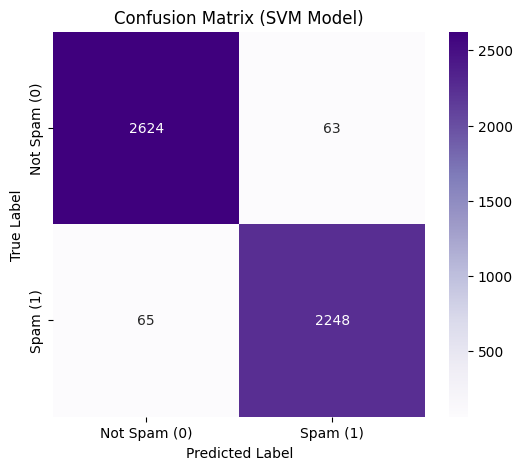

In [40]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Spam (0)', 'Spam (1)'],
            yticklabels=['Not Spam (0)', 'Spam (1)'])
plt.title('Confusion Matrix (SVM Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Fit model
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Accuracy: 0.9705813953488373

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97      4621
           1       0.97      0.97      0.97      3979

    accuracy                           0.97      8600
   macro avg       0.97      0.97      0.97      8600
weighted avg       0.97      0.97      0.97      8600



In [ ]:
# Cross validation check
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf_model, X_combined, y, cv=cv, scoring='accuracy')

print("cross-val accuracies:", scores)
print("Mean accuracy: {:.4f} ± {:.4f}".format(scores.mean(), scores.std()))

Naive Bayes cross-val accuracies: [0.97046512 0.96837209 0.9694186  0.96686047 0.96918246]
Mean accuracy: 0.9689 ± 0.0012


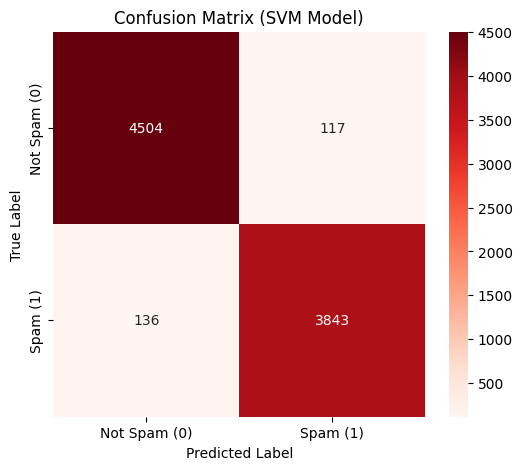

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Spam (0)', 'Spam (1)'],
            yticklabels=['Not Spam (0)', 'Spam (1)'])
plt.title('Confusion Matrix (SVM Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Slow comapred to other algorithms

## LGBM

In [41]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report

lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=-1,          # -1 = no limit
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lgbm))


[LightGBM] [Info] Number of positive: 9254, number of negative: 10746
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.327208 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 555485
[LightGBM] [Info] Number of data points in the train set: 20000, number of used features: 5648
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.462700 -> initscore=-0.149478
[LightGBM] [Info] Start training from score -0.149478
Accuracy: 0.9752

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.98      2687
           1       0.97      0.98      0.97      2313

    accuracy                           0.98      5000
   macro avg       0.97      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000



c:\Users\lle34\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# Cross validation check
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(lgbm_model, X_final, y, cv=cv, scoring='accuracy')

print("Naive Bayes cross-val accuracies:", scores)
print("Mean accuracy: {:.4f} ± {:.4f}".format(scores.mean(), scores.std()))

[LightGBM] [Info] Number of positive: 15915, number of negative: 18484
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.309998 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 529882
[LightGBM] [Info] Number of data points in the train set: 34399, number of used features: 4935
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.462659 -> initscore=-0.149643
[LightGBM] [Info] Start training from score -0.149643


c:\Users\lle34\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 15915, number of negative: 18484
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.268922 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 531050
[LightGBM] [Info] Number of data points in the train set: 34399, number of used features: 4939
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.462659 -> initscore=-0.149643
[LightGBM] [Info] Start training from score -0.149643


c:\Users\lle34\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 15915, number of negative: 18484
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.307252 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 531488
[LightGBM] [Info] Number of data points in the train set: 34399, number of used features: 4937
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.462659 -> initscore=-0.149643
[LightGBM] [Info] Start training from score -0.149643


c:\Users\lle34\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 15915, number of negative: 18484
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.285595 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 531737
[LightGBM] [Info] Number of data points in the train set: 34399, number of used features: 4940
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.462659 -> initscore=-0.149643
[LightGBM] [Info] Start training from score -0.149643


c:\Users\lle34\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 15916, number of negative: 18484
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.275798 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 527866
[LightGBM] [Info] Number of data points in the train set: 34400, number of used features: 4938
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.462674 -> initscore=-0.149581
[LightGBM] [Info] Start training from score -0.149581
Naive Bayes cross-val accuracies: [0.975      0.97604651 0.97802326 0.97360465 0.97755553]
Mean accuracy: 0.9760 ± 0.0016


c:\Users\lle34\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


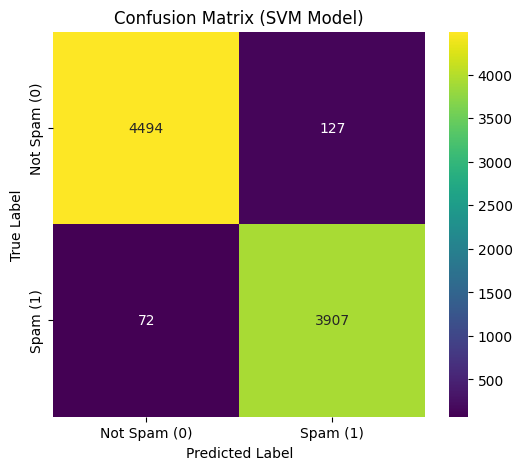

In [ ]:
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='viridis',
            xticklabels=['Not Spam (0)', 'Spam (1)'],
            yticklabels=['Not Spam (0)', 'Spam (1)'])
plt.title('Confusion Matrix (SVM Model)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()